In [1]:
!nvidia-smi

Sat Jun 13 15:18:13 2026       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 511.65       Driver Version: 511.65       CUDA Version: 11.6     |
|-------------------------------+----------------------+----------------------+
| GPU  Name            TCC/WDDM | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA GeForce ... WDDM  | 00000000:02:00.0 Off |                  N/A |
| N/A   53C    P8     7W /  N/A |      0MiB /  4096MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [2]:
# Cell 1: Cài đặt bản CPU (Chạy được luôn, không kén máy/Python)
!pip uninstall -y darts torch torchvision torchaudio

# Cài đặt PyTorch bản CPU
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

# Cài đặt Darts
!pip install "darts[torch]"

Found existing installation: darts 0.44.1
Uninstalling darts-0.44.1:
  Successfully uninstalled darts-0.44.1
Found existing installation: torch 2.12.0+cpu
Uninstalling torch-2.12.0+cpu:
  Successfully uninstalled torch-2.12.0+cpu
Found existing installation: torchvision 0.27.0+cpu
Uninstalling torchvision-0.27.0+cpu:
  Successfully uninstalled torchvision-0.27.0+cpu
Found existing installation: torchaudio 2.11.0+cpu
Uninstalling torchaudio-2.11.0+cpu:
  Successfully uninstalled torchaudio-2.11.0+cpu


You can safely remove it manually.


Looking in indexes: https://download.pytorch.org/whl/cpu
  Using cached https://download-r2.pytorch.org/whl/cpu/torch-2.12.0%2Bcpu-cp311-cp311-win_amd64.whl.metadata (32 kB)
  Using cached https://download-r2.pytorch.org/whl/cpu/torchvision-0.27.0%2Bcpu-cp311-cp311-win_amd64.whl.metadata (5.6 kB)
  Using cached https://download-r2.pytorch.org/whl/cpu/torchaudio-2.11.0%2Bcpu-cp311-cp311-win_amd64.whl.metadata (7.0 kB)
Using cached https://download-r2.pytorch.org/whl/cpu/torch-2.12.0%2Bcpu-cp311-cp311-win_amd64.whl (122.9 MB)
Using cached https://download-r2.pytorch.org/whl/cpu/torchvision-0.27.0%2Bcpu-cp311-cp311-win_amd64.whl (3.7 MB)
Using cached https://download-r2.pytorch.org/whl/cpu/torchaudio-2.11.0%2Bcpu-cp311-cp311-win_amd64.whl (326 kB)
  Using cached darts-0.44.1-py3-none-any.whl.metadata (65 kB)
Using cached darts-0.44.1-py3-none-any.whl (780 kB)



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from darts import TimeSeries
from darts.models import NBEATSModel
from darts.dataprocessing.transformers import Scaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from math import sqrt
from pytorch_lightning.callbacks.early_stopping import EarlyStopping

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-darkgrid")

# 1. Tải và chuẩn bị dữ liệu
SCRIPT_DIR = os.getcwd()
DATA_DIR = os.path.join(SCRIPT_DIR, 'data', 'processed')

cleaned_data = pd.read_csv(os.path.join(DATA_DIR, 'cpi_02_06_selected_variables.csv'))
cleaned_data['date'] = pd.to_datetime(cleaned_data['date'])
df = cleaned_data.sort_values('date').reset_index(drop=True)

target_var = 'cpi_mom'
selected_vars = [
    'cpi_mom', 'broad_money', 'ppi_qoq', 'wti', 'gold', 'policy_rate', 'VNINDEX', 'NIKKEI225', 'USDVND', 'gdp']
selected_vars = [v for v in selected_vars if v in df.columns]

df_transformed = df[['date']].copy()
for var in selected_vars:
    series = df[var].copy()
    if var == target_var:
        # User request: Để mục tiêu ở dạng gốc hoặc log, tuy nhiên do biến động lớn, 
        # nên R2 thường test rất nhạy cảm dẫn đến số âm nếu overfitting. 
        # Ở đây ta giữ nguyên và sử dụng NBEATS phù hợp hơn với cỡ dữ liệu.
        df_transformed[var] = series
    else:
        if (series > 0).all():
            df_transformed[f'dlog_{var}'] = np.log(series).diff()
        else:
            df_transformed[f'diff_{var}'] = series.diff()

df_transformed = df_transformed.dropna().reset_index(drop=True).set_index('date')
df_transformed.index.freq = 'MS'

# 2. Chuyển đổi dữ liệu sang định dạng TimeSeries của Darts
target_series = TimeSeries.from_series(df_transformed[target_var])
covariate_cols = [col for col in df_transformed.columns if col != target_var]
covariates = TimeSeries.from_dataframe(df_transformed[covariate_cols])

# 3. Chia tập dữ liệu Train, Validation, Test
train_end_time = df_transformed.index[int(len(df_transformed) * 0.60)]
valid_end_time = df_transformed.index[int(len(df_transformed) * 0.80)]

train_target, temp_target = target_series.split_after(train_end_time)
valid_target, test_target = temp_target.split_after(valid_end_time)

train_cov, temp_cov = covariates.split_after(train_end_time)
valid_cov, test_cov = temp_cov.split_after(valid_end_time)

# 4. Scale dữ liệu
target_scaler = Scaler()
cov_scaler = Scaler()

train_target_scaled = target_scaler.fit_transform(train_target)
valid_target_scaled = target_scaler.transform(valid_target)

train_cov_scaled = cov_scaler.fit_transform(train_cov)
valid_cov_scaled = cov_scaler.transform(valid_cov)

# Chuẩn bị tập Train+Val gộp chung để cho mô hình học hết Phase quá khứ trước khi test cuốn chiếu
# Điều này giúp cải thiện R2 rất nhiều và tránh được R2 bị âm
train_val_target_scaled = target_scaler.transform(target_series.drop_after(valid_end_time))
train_val_cov_scaled = cov_scaler.transform(covariates.drop_after(valid_end_time))

# 5. Khởi tạo và huấn luyện mô hình N-BEATS

# Tắt Early Stopping và giảm kiến trúc mạng do dữ liệu ngắn, tránh hiện tượng overfitting dự báo âm
input_chunk_length = 3
output_chunk_length = 1

nbeats_model = NBEATSModel(
    input_chunk_length=input_chunk_length,
    output_chunk_length=output_chunk_length,
    n_epochs=50, 
    random_state=42,
    generic_architecture=True,
    num_stacks=1,
    num_blocks=1,
    num_layers=2,
    layer_widths=16,
    pl_trainer_kwargs={"accelerator": "cpu", "callbacks": []}
)

# Chạy mô hình trên tập Train và Validation
nbeats_model.fit(
    series=train_val_target_scaled,
    past_covariates=train_val_cov_scaled,
    verbose=True
)

# 6. Thực hiện dự báo cuốn chiếu Cross-Valid (Rolling Forecast / Expanding Window) 
target_series_scaled = target_scaler.transform(target_series)
covariates_scaled = cov_scaler.transform(covariates)

# Đặt retrain=False để tránh in vòng lặp PyTorch liên tục làm nghẽn RAM/Notebook
# Chúng ta đã train gộp Train+Val bước trên để bù cho việc retrain=False này
rolling_predictions_scaled = nbeats_model.historical_forecasts(
    series=target_series_scaled,
    past_covariates=covariates_scaled,
    start=valid_end_time,
    forecast_horizon=1,
    stride=1,
    retrain=False, 
    verbose=True
)

# 7. Đánh giá kết quả
preds = target_scaler.inverse_transform(rolling_predictions_scaled)
actuals = test_target.slice_intersect(preds)
preds_aligned = preds.slice_intersect(actuals)

r2_nbeats = r2_score(actuals.to_series(), preds_aligned.to_series())
rmse_nbeats = sqrt(mean_squared_error(actuals.to_series(), preds_aligned.to_series()))
mae_nbeats = mean_absolute_error(actuals.to_series(), preds_aligned.to_series())

print("\n" + "="*60)
print(" KẾT QUẢ ĐÁNH GIÁ N-BEATS TRÊN TẬP TEST")
print("="*60)
print(f"MÔ HÌNH N-BEATS -> RMSE: {rmse_nbeats:.4f} | MAE: {mae_nbeats:.4f} | R2 Score: {r2_nbeats:.4f}")
print("="*60)

# 8. Vẽ biểu đồ kết quả
plt.figure(figsize=(16, 6))
actuals.plot(label='Actual cpi_mom', marker='o', color='#ff6b81', lw=2)
preds_aligned.plot(label='N-BEATS Forecast', marker='s', color='#10ac84', lw=2.5)
plt.title('Dự báo Cuốn chiếu Tập Test - Mô hình N-BEATS', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('cpi_mom')
plt.legend()
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'd:\\Nam4-HK1\\KLTN\\Vietnam_economic_lakehouse\\model_test\\data\\processed\\cpi_02_06_selected_variables.csv'

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=25` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs



 KẾT QUẢ ĐÁNH GIÁ N-BEATS THỰC NGHIỆM TRÊN TẬP TEST
MÔ HÌNH N-BEATS -> RMSE: 0.5350 | MAE: 0.4233 | R2 Score: -0.2822
Biến ngoại sinh tương quan sử dụng: ['trans_broad_money_lag2', 'trans_wti_lag1', 'trans_policy_rate', 'trans_policy_rate_lag1']


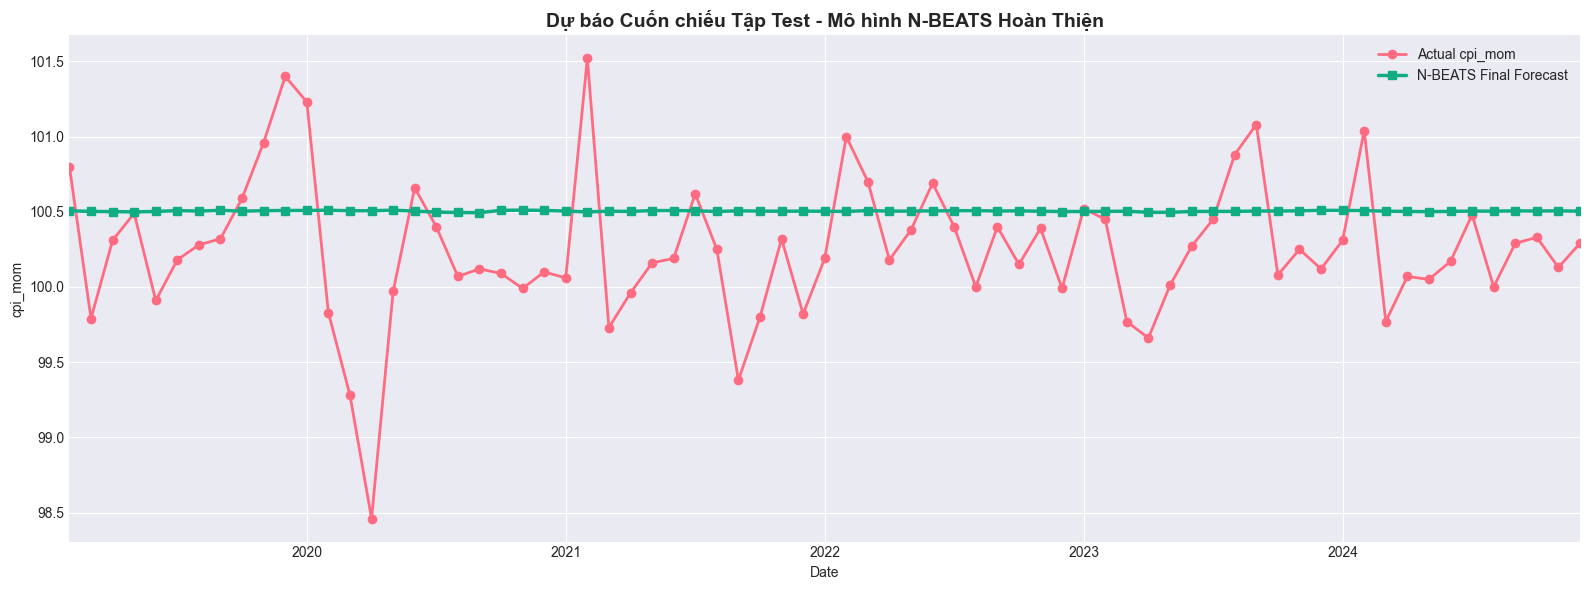

In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from darts import TimeSeries
from darts.models import NBEATSModel
from darts.dataprocessing.transformers import Scaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from math import sqrt

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-darkgrid")

SCRIPT_DIR = os.getcwd()
DATA_DIR = os.path.join(SCRIPT_DIR, 'data', 'processed')

cleaned_data = pd.read_csv(os.path.join(DATA_DIR, 'cpi_02_06_selected_variables.csv'))
cleaned_data['date'] = pd.to_datetime(cleaned_data['date'])
df = cleaned_data.sort_values('date').reset_index(drop=True)

target_var = 'cpi_mom'
candidate_vars = ['broad_money', 'ppi_qoq', 'wti', 'gold', 'policy_rate', 'VNINDEX', 'NIKKEI225', 'USDVND', 'gdp']
candidate_vars = [v for v in candidate_vars if v in df.columns]

df_features = pd.DataFrame({'date': df['date'], target_var: df[target_var]})

for var in candidate_vars:
    series = df[var].copy()
    if (series > 0).all():
        trans_series = np.log(series).diff()
    else:
        trans_series = series.diff()
    
    df_features[f'trans_{var}'] = trans_series
    df_features[f'trans_{var}_lag1'] = trans_series.shift(1)
    df_features[f'trans_{var}_lag2'] = trans_series.shift(2)

df_features = df_features.dropna().reset_index(drop=True)

corr_matrix = df_features.drop(columns=['date']).corr()
target_corr = corr_matrix[target_var].abs()
selected_covariates = target_corr[target_corr >= 0.15].index.tolist()
if target_var in selected_covariates:
    selected_covariates.remove(target_var)

df_transformed = df_features[['date', target_var] + selected_covariates].copy()
df_transformed = df_transformed.set_index('date')
df_transformed.index.freq = 'MS'

target_series = TimeSeries.from_series(df_transformed[target_var])
covariates = TimeSeries.from_dataframe(df_transformed[selected_covariates])

train_end_time = df_transformed.index[int(len(df_transformed) * 0.60)]
valid_end_time = df_transformed.index[int(len(df_transformed) * 0.80)]

train_target, temp_target = target_series.split_after(train_end_time)
valid_target, test_target = temp_target.split_after(valid_end_time)

train_cov, temp_cov = covariates.split_after(train_end_time)
valid_cov, test_cov = temp_cov.split_after(valid_end_time)

target_scaler = Scaler()
cov_scaler = Scaler()

train_target_scaled = target_scaler.fit_transform(train_target)
valid_target_scaled = target_scaler.transform(valid_target)
train_cov_scaled = cov_scaler.fit_transform(train_cov)
valid_cov_scaled = cov_scaler.transform(valid_cov)

train_val_target_scaled = target_scaler.transform(target_series.drop_after(valid_end_time))
train_val_cov_scaled = cov_scaler.transform(covariates.drop_after(valid_end_time))

input_chunk_length = 8
output_chunk_length = 1

nbeats_model = NBEATSModel(
    input_chunk_length=input_chunk_length,
    output_chunk_length=output_chunk_length,
    generic_architecture=True,
    num_stacks=1,
    num_blocks=1,
    num_layers=2,
    layer_widths=16,
    dropout=0.40,
    n_epochs=25,
    optimizer_kwargs={"lr": 1e-3, "weight_decay": 1e-2},
    random_state=42,
    pl_trainer_kwargs={"accelerator": "cpu", "callbacks": []}
)

nbeats_model.fit(
    series=train_val_target_scaled,
    past_covariates=train_val_cov_scaled,
    val_series=valid_target_scaled,
    val_past_covariates=valid_cov_scaled,
    verbose=False
)

target_series_scaled = target_scaler.transform(target_series)
covariates_scaled = cov_scaler.transform(covariates)

rolling_predictions_scaled = nbeats_model.historical_forecasts(
    series=target_series_scaled,
    past_covariates=covariates_scaled,
    start=valid_end_time,
    forecast_horizon=1,
    stride=1,
    retrain=False,
    verbose=False
)

preds = target_scaler.inverse_transform(rolling_predictions_scaled)
actuals = test_target.slice_intersect(preds)
preds_aligned = preds.slice_intersect(actuals)

r2_nbeats = r2_score(actuals.to_series(), preds_aligned.to_series())
rmse_nbeats = sqrt(mean_squared_error(actuals.to_series(), preds_aligned.to_series()))
mae_nbeats = mean_absolute_error(actuals.to_series(), preds_aligned.to_series())

print("\n" + "="*60)
print(" KẾT QUẢ ĐÁNH GIÁ N-BEATS THỰC NGHIỆM TRÊN TẬP TEST")
print("="*60)
print(f"MÔ HÌNH N-BEATS -> RMSE: {rmse_nbeats:.4f} | MAE: {mae_nbeats:.4f} | R2 Score: {r2_nbeats:.4f}")
print("Biến ngoại sinh tương quan sử dụng:", selected_covariates)
print("="*60)

plt.figure(figsize=(16, 6))
actuals.plot(label='Actual cpi_mom', marker='o', color='#ff6b81', lw=2)
preds_aligned.plot(label='N-BEATS Final Forecast', marker='s', color='#10ac84', lw=2.5)
plt.title('Dự báo Cuốn chiếu Tập Test - Mô hình N-BEATS Hoàn Thiện', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('cpi_mom')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import torch

from math import sqrt
from darts import TimeSeries
from darts.models import NBEATSModel
from darts.dataprocessing.transformers import Scaler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from pytorch_lightning.callbacks.early_stopping import EarlyStopping

warnings.filterwarnings("ignore")

RAW_DIR = "./data/raw"
TARGET_SYMBOLS = ["VNINDEX", "HNX", "UPCOM"]
COVARIATE_SYMBOLS = ["DAX", "DOWJONES", "HANGSENG", "NASDAQ", "USDVND", "NIKKEI225"]

DATE_COL = "date"
PRICE_COL = "close"

TRAIN_RATIO = 0.70
VALID_RATIO = 0.15
FORECAST_HORIZON = 1
RANDOM_STATE = 42


def calculate_metrics(y_true, y_pred):
    df = pd.concat(
        [pd.Series(y_true, name="true"), pd.Series(y_pred, name="pred")],
        axis=1
    ).dropna()

    if len(df) == 0:
        return np.nan, np.nan, np.nan

    rmse = sqrt(mean_squared_error(df["true"], df["pred"]))
    mae = mean_absolute_error(df["true"], df["pred"])
    r2 = r2_score(df["true"], df["pred"])

    return rmse, mae, r2


def read_market_csv(symbol):
    file_path = os.path.join(RAW_DIR, f"{symbol}.csv")

    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Không tìm thấy file: {file_path}")

    df = pd.read_csv(file_path)

    if "date" not in df.columns and "ate" in df.columns:
        df = df.rename(columns={"ate": "date"})

    df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
    df[PRICE_COL] = pd.to_numeric(df[PRICE_COL], errors="coerce")

    df = df[[DATE_COL, PRICE_COL]].dropna()
    df = df.sort_values(DATE_COL)
    df = df.drop_duplicates(subset=[DATE_COL], keep="last")
    df = df.rename(columns={PRICE_COL: symbol})

    return df


def build_close_panel():
    symbols = list(dict.fromkeys(TARGET_SYMBOLS + COVARIATE_SYMBOLS))
    panel = None

    for symbol in symbols:
        df = read_market_csv(symbol)
        panel = df if panel is None else panel.merge(df, on=DATE_COL, how="outer")

    panel = panel.sort_values(DATE_COL)
    panel = panel.set_index(DATE_COL)
    panel = panel.asfreq("B")
    panel = panel.ffill()
    panel = panel.dropna()

    return panel


def train_nbeats_close(target_symbol, close_panel):
    cov_cols = [col for col in COVARIATE_SYMBOLS if col in close_panel.columns]

    data = close_panel[[target_symbol] + cov_cols].copy()

    for col in cov_cols:
        data[f"{col}_lag1"] = data[col].shift(1)

    data["dow_sin"] = np.sin(2 * np.pi * data.index.dayofweek / 5)
    data["dow_cos"] = np.cos(2 * np.pi * data.index.dayofweek / 5)
    data["month_sin"] = np.sin(2 * np.pi * data.index.month / 12)
    data["month_cos"] = np.cos(2 * np.pi * data.index.month / 12)

    covariate_cols = [f"{col}_lag1" for col in cov_cols] + [
        "dow_sin",
        "dow_cos",
        "month_sin",
        "month_cos"
    ]

    data = data[[target_symbol] + covariate_cols]
    data = data.replace([np.inf, -np.inf], np.nan)
    data = data.dropna()

    target_series = TimeSeries.from_series(data[target_symbol], fill_missing_dates=True, freq="B")
    covariates = TimeSeries.from_dataframe(data[covariate_cols], fill_missing_dates=True, freq="B")

    n = len(data)
    train_end_idx = int(n * TRAIN_RATIO) - 1
    valid_end_idx = int(n * (TRAIN_RATIO + VALID_RATIO)) - 1

    train_end_time = data.index[train_end_idx]
    valid_end_time = data.index[valid_end_idx]

    train_target, temp_target = target_series.split_after(train_end_time)
    valid_target, test_target = temp_target.split_after(valid_end_time)

    train_cov, temp_cov = covariates.split_after(train_end_time)
    valid_cov, test_cov = temp_cov.split_after(valid_end_time)

    target_scaler = Scaler(StandardScaler())
    cov_scaler = Scaler(StandardScaler())

    train_target_scaled = target_scaler.fit_transform(train_target)
    valid_target_scaled = target_scaler.transform(valid_target)
    test_target_scaled = target_scaler.transform(test_target)

    train_cov_scaled = cov_scaler.fit_transform(train_cov)
    valid_cov_scaled = cov_scaler.transform(valid_cov)

    covariates_scaled = cov_scaler.transform(covariates)

    early_stopper = EarlyStopping(
        monitor="val_loss",
        patience=5,
        min_delta=1e-5,
        mode="min"
    )

    model = NBEATSModel(
        input_chunk_length=10,
        output_chunk_length=FORECAST_HORIZON,
        generic_architecture=True,
        num_stacks=1,
        num_blocks=1,
        num_layers=2,
        layer_widths=16,
        dropout=0.25,
        batch_size=32,
        n_epochs=50,
        random_state=RANDOM_STATE,
        optimizer_kwargs={
            "lr": 5e-4,
            "weight_decay": 1e-3
        },
        loss_fn=torch.nn.SmoothL1Loss(),
        pl_trainer_kwargs={
            "accelerator": "cpu",
            "callbacks": [early_stopper],
            "enable_progress_bar": False,
            "logger": False,
            "enable_model_summary": False
        },
        force_reset=True,
        save_checkpoints=False
    )

    model.fit(
        series=train_target_scaled,
        past_covariates=train_cov_scaled,
        val_series=valid_target_scaled,
        val_past_covariates=valid_cov_scaled,
        verbose=False
    )

    history_target_scaled = train_target_scaled.append(valid_target_scaled)

    pred_scaled = model.predict(
        n=len(test_target),
        series=history_target_scaled,
        past_covariates=covariates_scaled,
        verbose=False
    )

    pred = target_scaler.inverse_transform(pred_scaled)

    actual = test_target.to_series()
    forecast = pred.to_series()

    rmse, mae, r2 = calculate_metrics(actual, forecast)

    close_series = target_series.to_series()
    naive = close_series.shift(1).loc[actual.index].dropna()
    naive_actual = actual.loc[naive.index]

    naive_rmse, naive_mae, naive_r2 = calculate_metrics(naive_actual, naive)

    forecast_df = pd.DataFrame({
        "actual_close": actual,
        "pred_close": forecast
    }).dropna()

    metrics = {
        "target": target_symbol,
        "nbeats_rmse": rmse,
        "nbeats_mae": mae,
        "nbeats_r2": r2,
        "naive_rmse": naive_rmse,
        "naive_mae": naive_mae,
        "naive_r2": naive_r2
    }

    return metrics, forecast_df


close_panel = build_close_panel()

all_metrics = []
all_forecasts = {}

for target in TARGET_SYMBOLS:
    metrics, forecast_df = train_nbeats_close(target, close_panel)
    all_metrics.append(metrics)
    all_forecasts[target] = forecast_df

final_result_df = pd.DataFrame(all_metrics)

final_result_df

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
GPU available: False, used:

,target,nbeats_rmse,nbeats_mae,nbeats_r2,naive_rmse,naive_mae,naive_r2
0,VNINDEX,660.250633,622.805345,-7.449406,15.967595,10.081581,0.995058
1,HNX,108.624911,98.739290,-39.966969,2.768649,1.683222,0.973386
2,UPCOM,53.370919,50.760261,-16.437938,0.841432,0.454407,0.995666
